In [1]:
# ==================== 1. INSTALL LIBRARIES ====================
!pip install transformers datasets accelerate -q
!pip install torch torchvision torchaudio -q
!pip install scikit-learn matplotlib seaborn pandas numpy tqdm -q

In [2]:
# ==================== 2. IMPORTS ====================
import os, time, random, json, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    TrainerCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

warnings.filterwarnings("ignore")
os.environ["WANDB_DISABLED"] = "true"

In [3]:
# ==================== 3. SET SEED ====================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


# ==================== 4. DEVICE ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [6]:
# ==================== 5. LOAD DATA (SMART SAMPLING) ====================
def load_dataset(path, sample_size=20000):
    df = pd.read_csv(path)
    df["review"] = df["review"].str.replace("<br />", " ", regex=False)

    df = df.groupby("sentiment", group_keys=False).apply(
        lambda x: x.sample(sample_size // 2, random_state=42)
    ).sample(frac=1, random_state=42).reset_index(drop=True)

    df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})
    return df

df = load_dataset("/content/drive/MyDrive/Colab Notebooks/IMDB Dataset.csv")

In [7]:
# ==================== 6. SPLIT ====================
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.67, stratify=temp_df["label"], random_state=42)

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [8]:
# ==================== 7. TOKENIZER ====================
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
# ==================== 8. DATASET CLASS ====================
class IMDBDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.df.loc[idx, "review"],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels": torch.tensor(self.df.loc[idx, "label"], dtype=torch.long)
        }

train_dataset = IMDBDataset(train_df, tokenizer)
val_dataset = IMDBDataset(val_df, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

In [10]:
# ==================== 9. MODEL ====================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
# ==================== 10. METRICS ====================
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [12]:
# ==================== 11. PATHS ====================
CHECKPOINT_DIR = "/content/drive/MyDrive/imdb_checkpoints"
FINAL_MODEL_DIR = "/content/drive/MyDrive/sentiment_model"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [13]:
# ==================== 12. TRAINING ARGS ====================
training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=200,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=42,
    report_to="none"
)

In [14]:
# ==================== 13. TRAINER ====================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [30]:
# ==================== 14. TRAINING WITH RESUME ====================
from transformers.trainer_utils import get_last_checkpoint

start_time = time.time()
last_checkpoint = get_last_checkpoint(CHECKPOINT_DIR)

if last_checkpoint:
    print(f"Resuming from checkpoint {last_checkpoint}")
    trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    trainer.train()

end_time = time.time()
training_time = (end_time - start_time)/60
print(f"Training Time: {training_time:.2f} min")

Resuming from checkpoint /content/drive/MyDrive/imdb_checkpoints/checkpoint-15750


There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Epoch,Training Loss,Validation Loss,Accuracy
10,0.020429,1.163619,0.879737


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training Time: 3.58 min


In [31]:
# ==================== 15. SAVE MODEL ====================
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/sentiment_model/tokenizer_config.json',
 '/content/drive/MyDrive/sentiment_model/tokenizer.json')

In [32]:
# ==================== 16. EVALUATION ====================
val_results = trainer.evaluate()
test_preds = trainer.predict(test_dataset)
test_metrics = compute_metrics(test_preds)

print("Validation:", val_results)
print(f"Test Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Test Precision: {test_metrics['precision']:.4f}")
print(f"Test Recall:    {test_metrics['recall']:.4f}")
print(f"Test F1:        {test_metrics['f1']:.4f}")

Validation: {'eval_loss': 0.4061107635498047, 'eval_accuracy': 0.8827690752905508, 'eval_runtime': 9.0078, 'eval_samples_per_second': 219.699, 'eval_steps_per_second': 27.532, 'epoch': 10.0}
Test Accuracy: 0.8756528226809251


In [33]:
# ==================== 17. SAVE METRICS ====================
# Find the best validation metrics from trainer log history
best_val_acc = 0.0
best_val_metrics = {}
for entry in trainer.state.log_history:
    if "eval_accuracy" in entry:
        if entry["eval_accuracy"] > best_val_acc:
            best_val_acc = entry["eval_accuracy"]
            best_val_metrics = {
                "eval_accuracy": entry.get("eval_accuracy", 0),
                "eval_precision": entry.get("eval_precision", 0),
                "eval_recall": entry.get("eval_recall", 0),
                "eval_f1": entry.get("eval_f1", 0),
                "eval_loss": entry.get("eval_loss", 0),
                "epoch": entry.get("epoch", 0),
            }

metrics = {
    "validation_results": val_results,
    "best_validation": best_val_metrics,
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "training_time_min": training_time,
}

with open(os.path.join(FINAL_MODEL_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved metrics.json with accuracy, precision, recall, F1!")

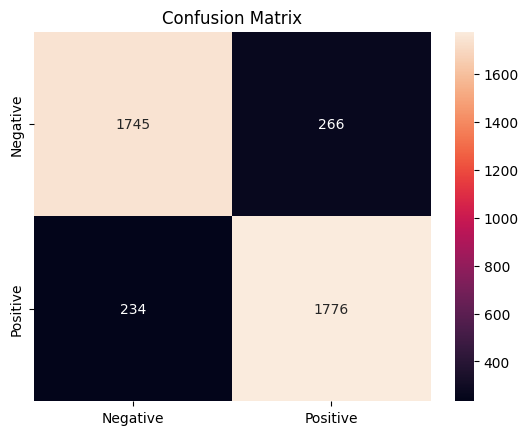

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      2011
           1       0.87      0.88      0.88      2010

    accuracy                           0.88      4021
   macro avg       0.88      0.88      0.88      4021
weighted avg       0.88      0.88      0.88      4021



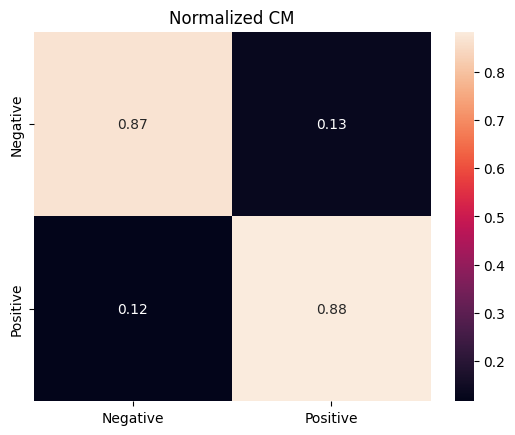

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      2011
           1       0.87      0.88      0.88      2010

    accuracy                           0.88      4021
   macro avg       0.88      0.88      0.88      4021
weighted avg       0.88      0.88      0.88      4021



In [34]:
# ==================== 18. CONFUSION MATRIX ====================
def plot_confusion_matrix(dataset, normalize=False):
    loader = DataLoader(dataset, batch_size=8)
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            outputs = model(
                batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device)
            )
            preds = torch.argmax(outputs.logits, dim=1)
            y_true.extend(batch["labels"].numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm, annot=True,
                fmt=".2f" if normalize else "d",
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    plt.title("Normalized CM" if normalize else "Confusion Matrix")
    plt.show()

    print(classification_report(y_true, y_pred))


plot_confusion_matrix(test_dataset, normalize=False)
plot_confusion_matrix(test_dataset, normalize=True)

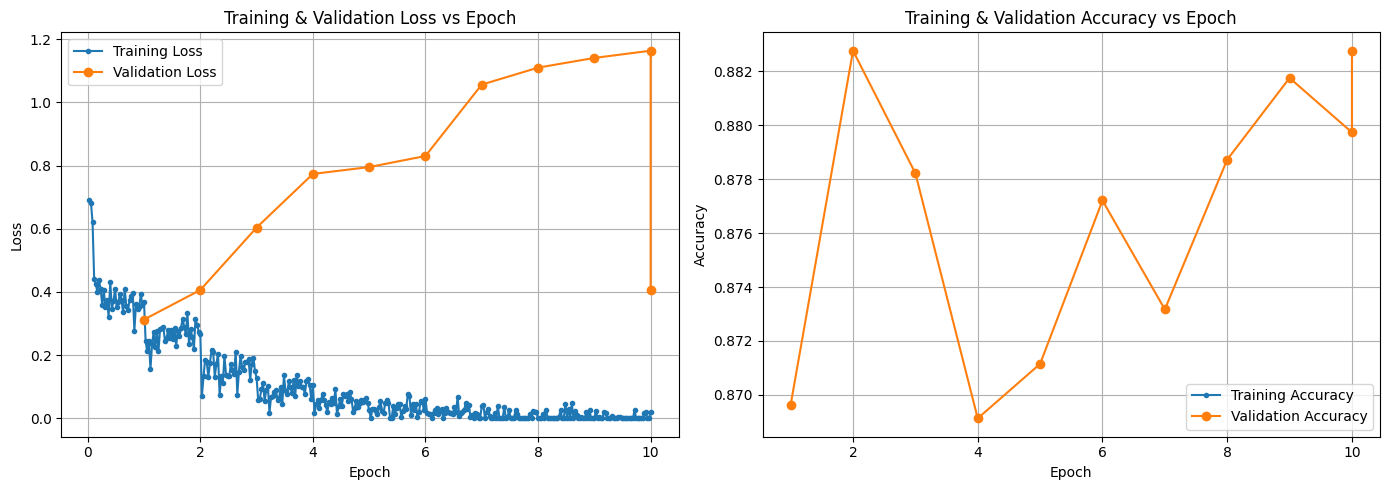

In [36]:
# ==================== 19. TRAINING + VALIDATION GRAPHS (WITH TRAIN ACC) ====================
log_history = trainer.state.log_history

train_epochs = []
train_losses = []
train_accuracies = []

val_epochs = []
val_losses = []
val_accuracies = []

for log in log_history:
    if "loss" in log and "epoch" in log and "eval_loss" not in log:
        # This is a training step log
        train_epochs.append(log["epoch"])
        train_losses.append(log["loss"])
        train_accuracies.append(log.get("accuracy", None)) # Get accuracy if present
    elif "eval_loss" in log and "eval_accuracy" in log and "epoch" in log:
        # This is an evaluation log
        val_epochs.append(log["epoch"])
        val_losses.append(log["eval_loss"])
        val_accuracies.append(log["eval_accuracy"])

# Convert None to NaN for plotting (as accuracy is not logged for training steps by default)
train_accuracies_plot = [x if x is not None else np.nan for x in train_accuracies]

plt.figure(figsize=(14,5))

# Loss subplot
plt.subplot(1,2,1)
plt.plot(train_epochs, train_losses, marker='.', linestyle='-', label="Training Loss")
plt.plot(val_epochs, val_losses, marker='o', linestyle='-', label="Validation Loss")
plt.title("Training & Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy subplot
plt.subplot(1,2,2)
plt.plot(train_epochs, train_accuracies_plot, marker='.', linestyle='-', label="Training Accuracy")
plt.plot(val_epochs, val_accuracies, marker='o', linestyle='-', label="Validation Accuracy")
plt.title("Training & Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
# ==================== 20. PREDICTION FUNCTION ====================
def predict_sentiment(text):
    model.eval()
    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1)

    label = torch.argmax(probs).item()
    return {"sentiment": "positive" if label == 1 else "negative",
            "confidence": probs[0][label].item()}

In [38]:
# ==================== 21. SAMPLE TEST ====================
print(predict_sentiment("This movie was so boring!"))

{'sentiment': 'negative', 'confidence': 0.9984872341156006}


In [39]:
# ==================== 22. CLASSIFICATION TABLE ====================
from sklearn.metrics import classification_report

def classification_table(dataset, save_path=None):
    loader = DataLoader(dataset, batch_size=8)
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            outputs = model(
                batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device)
            )
            preds = torch.argmax(outputs.logits, dim=1)
            y_true.extend(batch["labels"].numpy())
            y_pred.extend(preds.cpu().numpy())

    # Generate classification report (dictionary format)
    report = classification_report(y_true, y_pred, target_names=["Negative", "Positive"], output_dict=True)

    # Convert to DataFrame for easier viewing / saving
    report_df = pd.DataFrame(report).transpose()

    # Display table
    print("\nClassification Table:")
    display(report_df)

    # Save CSV if path provided
    if save_path:
        report_df.to_csv(save_path, index=True)
        print(f"Classification table saved to {save_path}")

    return report_df


# Example usage: save to metrics folder
classification_df = classification_table(test_dataset, save_path=os.path.join(FINAL_MODEL_DIR, "classification_table.csv"))


Classification Table:


,precision,recall,f1-score,support
Negative,0.881758,0.867727,0.874687,2011.000000
Positive,0.869736,0.883582,0.876604,2010.000000
accuracy,0.875653,0.875653,0.875653,0.875653
macro avg,0.875747,0.875655,0.875645,4021.000000
weighted avg,0.875749,0.875653,0.875645,4021.000000


Classification table saved to /content/drive/MyDrive/sentiment_model/classification_table.csv
